# Prophet
- Facebook에서 개발한 시계열 예측을 위한 라이브러리
- 자동화된 시계열 예측 기능을 제공하여 사용이 간편함
- 트렌드(Trend), 계절성(Seasonality), 휴일 효과(Holiday Effect) 등을 반영 가능
- 비정상적 데이터 변동을 감지하고 처리하는 기능 제공
- 금융, 마케팅, 수요 예측 등 다양한 분야에서 활용
- https://github.com/facebook/prophet?tab=readme-ov-file


- Prophet의 특징
    - 선형 및 비선형 트렌드 예측 가능
    - 연간, 주간, 일간 계절성 반영 가능
    - 공휴일 및 특별한 이벤트를 모델에 포함 가능
    - 결측치와 이상치 처리가 용이
    - 자동으로 최적의 하이퍼파라미터 조정 가능

In [ ]:
# %pip install prophet
# uv add prophet

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

c:\Users\playdata2\work_space(playdata)\SKN30_playdata\LLM\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
stock = yf.download('005930.KS', start='2021-06-04', end='2026-06-04')
stock = stock.reset_index()

stock.columns = stock.columns.droplevel(1)
stock.tail()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
1214,2026-05-27,307000.0,323000.0,306000.0,321500.0,33916688
1215,2026-05-28,299500.0,306500.0,287500.0,305000.0,30195334
1216,2026-05-29,317000.0,319000.0,305500.0,309500.0,37241537
1217,2026-06-01,349000.0,354500.0,319500.0,319500.0,45052488
1218,2026-06-02,360500.0,370000.0,342000.0,360500.0,44720282


In [15]:
# Prophet은 입력 데이터 컬럼명을 반드시 ds, y로 요구
# ds : 날짜, y : 예측 대상 값(종가 close)
stock = stock[['Date', 'Close']]
stock.columns = ['ds', 'y']             # prophet에 맞게 컬럼명 변경

In [17]:
import os
from importlib import resources
from prophet.models import CmdStanPyBackend

def add_prophet_tbb_to_path():
    tbb_dir = resources.files('prophet') / 'stan_model' / f'cmdstan-{CmdStanPyBackend.CMDSTAN_VERSION}' / 'stan' / 'lib' / 'stan_math' / 'lib' / 'tbb'
    if not tbb_dir.exists():
        return None

    path_parts = os.environ.get('PATH', '').split(os.pathsep)
    if str(tbb_dir) not in path_parts:
        os.environ['PATH'] = str(tbb_dir) + os.pathsep + os.environ.get('PATH', '')
    os.environ['STAN_TBB'] = str(tbb_dir)
    return tbb_dir

add_prophet_tbb_to_path()

warnings.filterwarnings('ignore')

In [18]:
# 모델 학습
# yearly_seasonality : 연 단위 반복 패턴을 모델이 고려하도록 설정

# CMDSTANPY가 tbb.dll을 찾도록 보정
add_prophet_tbb_to_path()

model = Prophet(yearly_seasonality=True, stan_backend='CMDSTANPY')
model.fit(stock)

09:43:55 - cmdstanpy - INFO - Chain [1] start processing
09:43:56 - cmdstanpy - INFO - Chain [1] done processing


In [20]:
# 미래 데이터 생성(예측기간 60일)
future = model.make_future_dataframe(periods=60)
forecast = model.predict(future)

<Figure size 1200x600 with 0 Axes>

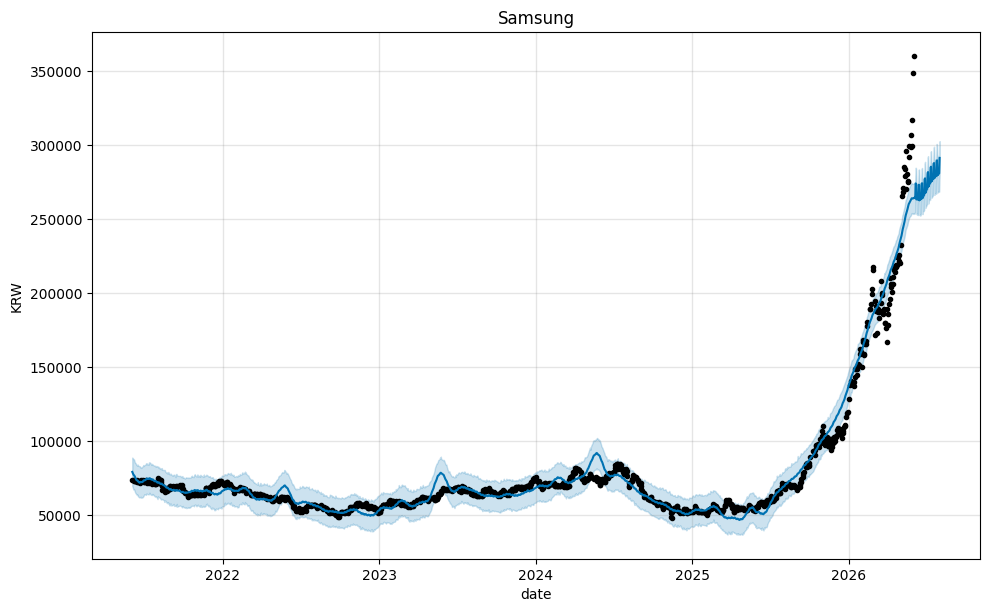

In [21]:
plt.figure(figsize=(12,6))
model.plot(forecast)            # prophet의 기본 plot으로 실제 데이터와 예측 추세를 함께 확인
plt.title('Samsung')
plt.xlabel('date')
plt.ylabel('KRW')
plt.show()

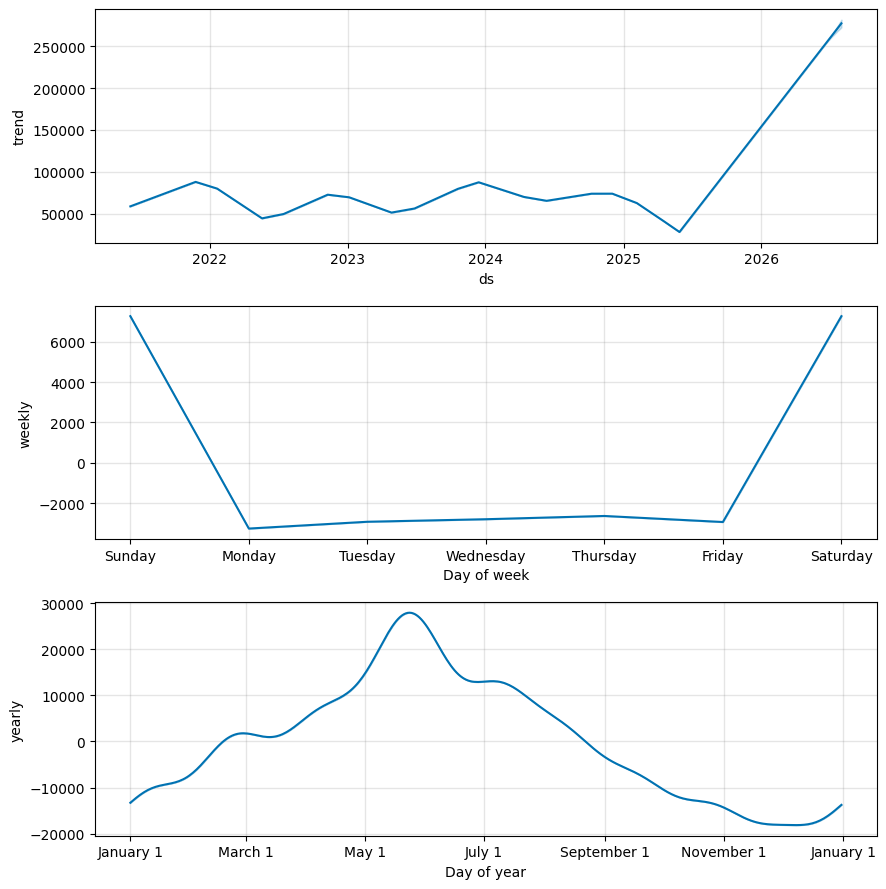

: 

In [ ]:
# 예측 결과를 추세와 계절성 구성 요소로 분해
# plot_components : 모델이 어떤 패턴을 근거로 예측했는지 해석할 때 유용
fig2 = model.plot_components(forecast)